# Harder regression: integrated-gradient explanation fidelity

This notebook compares feature attributions from the 20-member linear MiSTIC
set with those from the full-training-data linear SVR on MiSTIC's knee-ranked
unified features. The true feature structure is known: features 0–9 directly
generate the target, features 10–19 are noisy redundant proxies, and features
20–99 are noise.

The reference point is zero in standardized feature space—the training mean.
For a linear SVR, standard integrated gradients are exact:
`IG_j = (x_j - reference_j) * w_j`. The notebook evaluates:

1. MiSTIC's **current SVR IG formula**, analytically reproduced for the linear
   kernel.
2. **Standard completeness-preserving IG** averaged across MiSTIC members,
   assigning zero to features absent from a member.
3. Standard IG for the **full-data unified-feature SVR**.

Attribution quality is assessed without blind-label leakage using known signal
identities, global attribution mass, top-feature recovery, average precision,
seed stability, and completeness error.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import (average_precision_score, mean_absolute_error,
                             root_mean_squared_error, r2_score)
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.75
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]
POLY_DEGREES = [2, 3]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=60.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.30 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=1.42e-17, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models, kernel_type):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type=kernel_type),
        separate_feature_sets=True, separate_parameters=True,
    )
    if kernel_type == "linear":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon}, kernel={})
            for c in C_VALUES for epsilon in EPSILON_VALUES
        ]
    elif kernel_type == "rbf":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon},
                     kernel={"gamma": gamma})
            for c in C_VALUES for gamma in GAMMA_VALUES
            for epsilon in EPSILON_VALUES
        ]
    elif kernel_type == "polynomial":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon},
                     kernel={"gamma": gamma, "degree": degree, "coef0": 1.0})
            for c in C_VALUES for gamma in GAMMA_VALUES
            for epsilon in EPSILON_VALUES for degree in POLY_DEGREES
        ]
    else:
        raise ValueError(kernel_type)
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run the attribution comparison

Models are fitted exactly as in the harder linear benchmark. Integrated
gradients are evaluated for every blind input, but blind target values are not
used to construct or rank explanations.


In [4]:
NUM_MODELS = 20
explanation_rows = []
importance_rows = []

def attribution_metrics(values, prediction_delta, method, seed):
    global_importance = np.mean(np.abs(values), axis=0)
    ranking = np.argsort(-global_importance, kind="stable")
    signal_mask = np.zeros(N_FEATURES, dtype=int)
    signal_mask[:N_INFORMATIVE + N_REDUNDANT] = 1
    total_mass = global_importance.sum()
    return {
        "seed": seed,
        "method": method,
        "top20_signal_recall": len(set(ranking[:20]).intersection(SIGNAL_FEATURES)) / 20,
        "top10_direct_recall": len(set(ranking[:10]).intersection(range(10))) / 10,
        "signal_attribution_fraction": global_importance[:20].sum() / total_mass,
        "direct_attribution_fraction": global_importance[:10].sum() / total_mass,
        "feature_average_precision": average_precision_score(signal_mask, global_importance),
        "completeness_mae": np.mean(np.abs(values.sum(axis=1) - prediction_delta)),
    }, global_importance


for seed in INNER_SEEDS:
    scaler, ensemble, knee_count = fit_mistic(seed, NUM_MODELS, "linear")
    X_blind_scaled = scaler.transform(X_blind)
    set_predictions = np.asarray(ensemble.predict(X_blind_scaled))

    # Exact linear weights for each precomputed-kernel member.
    standard_set_ig = np.zeros((len(X_blind), N_FEATURES))
    current_set_ig = np.zeros((len(X_blind), N_FEATURES))
    member_baselines = []
    for model_index in range(NUM_MODELS):
        features = np.asarray(ensemble.features[model_index], dtype=int)
        support_vectors = ensemble._get_support_vectors(model_index)
        weights = ensemble.models[model_index].dual_coef_[0] @ support_vectors[:, features]
        intercept = float(ensemble.models[model_index].intercept_[0])
        raw_ig = X_blind_scaled[:, features] * weights
        standard_set_ig[:, features] += raw_ig / NUM_MODELS
        # Exact algebraic equivalent of the current SVR branch in
        # svmSet.integrated_gradient for a zero reference and linear kernel.
        current_set_ig[:, features] += (
            (raw_ig + intercept) / len(features) / NUM_MODELS
        )
        member_baselines.append(intercept)
    set_delta = set_predictions - np.mean(member_baselines)

    unified_features = ranked_unified_features(ensemble, knee_count)
    full_scaler = StandardScaler().fit(X_train.iloc[:, unified_features])
    X_train_full_scaled = full_scaler.transform(X_train.iloc[:, unified_features])
    X_blind_full_scaled = full_scaler.transform(X_blind.iloc[:, unified_features])
    full_search = GridSearchCV(
        SVR(kernel="linear"),
        {"C": C_VALUES, "epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    ).fit(X_train_full_scaled, y_train)
    full_model = full_search.best_estimator_
    full_weights = full_model.dual_coef_[0] @ full_model.support_vectors_
    full_ig = np.zeros((len(X_blind), N_FEATURES))
    full_ig[:, unified_features] = X_blind_full_scaled * full_weights
    full_predictions = full_model.predict(X_blind_full_scaled)
    full_delta = full_predictions - float(full_model.intercept_[0])

    conditions = [
        ("svmSet current SVR IG", current_set_ig, set_delta),
        ("svmSet standard IG", standard_set_ig, set_delta),
        ("Full-data unified SVR standard IG", full_ig, full_delta),
    ]
    for method, values, delta in conditions:
        row, global_importance = attribution_metrics(values, delta, method, seed)
        row["knee_feature_count"] = knee_count
        row["prediction_r2"] = (
            r2_score(y_blind, set_predictions)
            if method.startswith("svmSet") else r2_score(y_blind, full_predictions)
        )
        explanation_rows.append(row)
        importance_rows.extend({
            "seed": seed, "method": method, "feature": feature,
            "global_importance": importance,
            "feature_type": ("direct" if feature < 10 else
                             "redundant" if feature < 20 else "noise"),
        } for feature, importance in enumerate(global_importance))
    print(f"completed seed={seed}, knee={knee_count}")

explanation_results = pd.DataFrame(explanation_rows)
importance_results = pd.DataFrame(importance_rows)
explanation_results.to_csv(
    repo_root / "validation/Synthetic100_regression_harder_ig_comparison_10seeds_results.csv",
    index=False,
)
importance_results.to_csv(
    repo_root / "validation/Synthetic100_regression_harder_ig_comparison_10seeds_importance.csv",
    index=False,
)
explanation_results


Number of Features: 1, Score: 0.075


Number of Features: 10, Score: 0.658


Number of Features: 19, Score: 0.808


Number of Features: 20, Score: 0.809


Number of Features: 100, Score: 0.784


...

Number of Features: 19, Score: 0.807


Number of Features: 20, Score: 0.811


Number of Features: 100, Score: 0.789


completed seed=9, knee=19


,seed,method,top20_signal_recall,top10_direct_recall,signal_attribution_fraction,direct_attribution_fraction,feature_average_precision,completeness_mae,knee_feature_count,prediction_r2
0,0,svmSet current SVR IG,0.85,0.8,0.903845,0.692644,0.954352,5.949799e-01,19,0.775632
1,0,svmSet standard IG,0.85,0.8,0.910825,0.699589,0.948320,1.174670e-14,19,0.775632
2,0,Full-data unified SVR standard IG,0.80,1.0,0.960191,0.878740,0.777079,6.311840e-15,19,0.812237
3,1,svmSet current SVR IG,0.85,0.8,0.912424,0.723525,0.935691,5.997687e-01,19,0.790968
4,1,svmSet standard IG,0.85,0.8,0.914718,0.726571,0.926879,9.557292e-15,19,0.790968
5,1,Full-data unified SVR standard IG,0.85,0.8,0.977285,0.821334,0.819318,5.575318e-15,19,0.809588
6,2,svmSet current SVR IG,0.75,0.9,0.901878,0.715737,0.873041,5.973448e-01,19,0.785262
7,2,svmSet standard IG,0.75,0.9,0.906789,0.721335,0.869907,1.254608e-14,19,0.785262
8,2,Full-data unified SVR standard IG,0.85,0.8,0.982232,0.814348,0.831319,8.868795e-15,19,0.803935
9,3,svmSet current SVR IG,0.80,0.9,0.899342,0.744575,0.892128,6.104308e-01,20,0.788130


In [5]:
summary = explanation_results.groupby("method")[[
    "top20_signal_recall", "top10_direct_recall", "signal_attribution_fraction",
    "direct_attribution_fraction", "feature_average_precision",
    "completeness_mae", "prediction_r2"
]].agg(["mean", "std"])
summary.round(5)


top20_signal_recall           \
                                                 mean      std   
method                                                           
Full-data unified SVR standard IG                0.80  0.05774   
svmSet current SVR IG                            0.83  0.03496   
svmSet standard IG                               0.83  0.03496   

                                  top10_direct_recall           \
                                                 mean      std   
method                                                           
Full-data unified SVR standard IG                0.82  0.06325   
svmSet current SVR IG                            0.87  0.04830   
svmSet standard IG                               0.87  0.04830   

                                  signal_attribution_fraction           \
                                                         mean      std   
method                                                                   
Full-data unified SVR standard IG                     0.96816  0.01287   
svmSet current SVR IG                                 0.90440  0.00784   
svmSet standard IG                                    0.91098  0.00665   

                                  direct_attribution_fraction           \
                                                         mean      std   
method                                                                   
Full-data unified SVR standard IG                     0.81345  0.03603   
svmSet current SVR IG                                 0.72116  0.03225   
svmSet standard IG                                    0.72858  0.03259   

                                  feature_average_precision           \
                                                       mean      std   
method                                                                 
Full-data unified SVR standard IG                   0.79061  0.03708   
svmSet current SVR IG                               0.92489  0.02504   
svmSet standard IG                                  0.91755  0.02326   

                                  completeness_mae          prediction_r2  \
                                              mean      std          mean   
method                                                                      
Full-data unified SVR standard IG          0.00000  0.00000       0.80859   
svmSet current SVR IG                      0.59987  0.00911       0.78306   
svmSet standard IG                         0.00000  0.00000       0.78306   

                                            
                                       std  
method                                      
Full-data unified SVR standard IG  0.00610  
svmSet current SVR IG              0.00911  
svmSet standard IG                 0.00911

In [6]:
stability_rows = []
for method, frame in importance_results.groupby("method"):
    wide = frame.pivot(index="seed", columns="feature", values="global_importance")
    correlations = []
    jaccards = []
    for first in range(len(wide)):
        for second in range(first + 1, len(wide)):
            correlations.append(spearmanr(wide.iloc[first], wide.iloc[second]).statistic)
            top_first = set(np.argsort(-wide.iloc[first].to_numpy())[:20])
            top_second = set(np.argsort(-wide.iloc[second].to_numpy())[:20])
            jaccards.append(len(top_first & top_second) / len(top_first | top_second))
    stability_rows.append({
        "method": method,
        "mean_seed_spearman": np.mean(correlations),
        "mean_top20_jaccard": np.mean(jaccards),
    })
stability = pd.DataFrame(stability_rows)
stability.round(5)


,method,mean_seed_spearman,mean_top20_jaccard
0,Full-data unified SVR standard IG,0.83171,0.68378
1,svmSet current SVR IG,0.79694,0.70297
2,svmSet standard IG,0.79283,0.70458


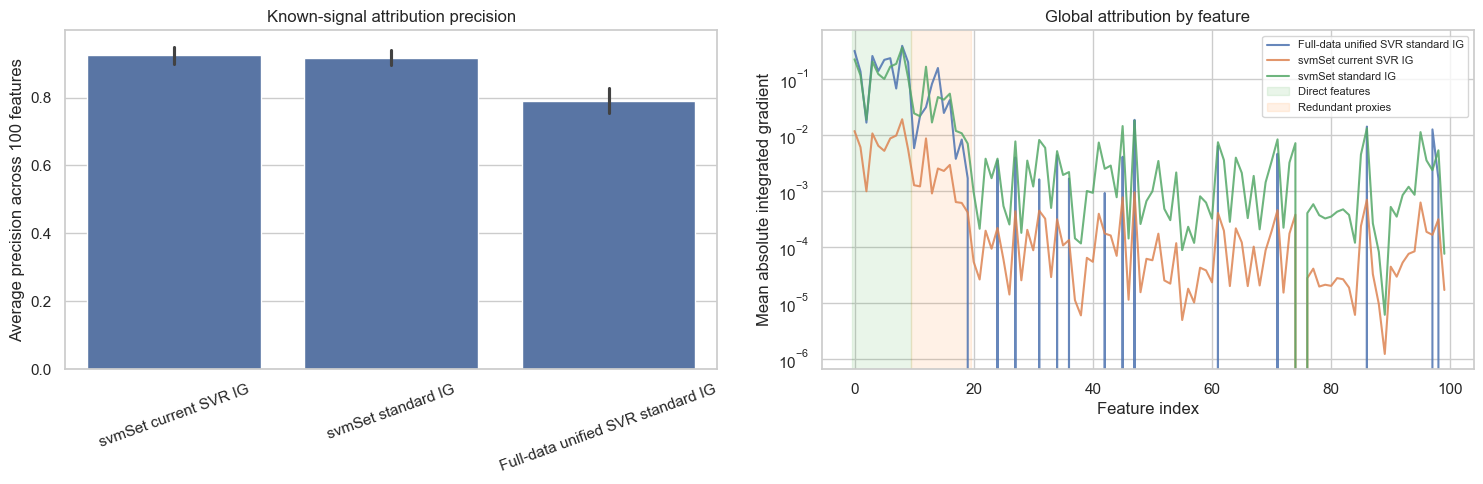

In [7]:
mean_importance = (
    importance_results.groupby(["method", "feature", "feature_type"], as_index=False)
    ["global_importance"].mean()
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=explanation_results, x="method", y="feature_average_precision",
            errorbar="sd", ax=axes[0])
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_title("Known-signal attribution precision")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average precision across 100 features")

for method, frame in mean_importance.groupby("method"):
    axes[1].plot(frame["feature"], frame["global_importance"], label=method, alpha=0.85)
axes[1].axvspan(-0.5, 9.5, color="tab:green", alpha=0.10, label="Direct features")
axes[1].axvspan(9.5, 19.5, color="tab:orange", alpha=0.10, label="Redundant proxies")
axes[1].set_yscale("log")
axes[1].set_xlabel("Feature index")
axes[1].set_ylabel("Mean absolute integrated gradient")
axes[1].set_title("Global attribution by feature")
axes[1].legend(fontsize=8)
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_harder_ig_comparison_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

Feature-recovery metrics use only known feature identities; blind targets do
not influence the explanations. Standard IG completeness is evaluated against
`prediction - prediction(reference)`. The current MiSTIC SVR formula is also
evaluated against that standard definition to expose any scaling or baseline
allocation mismatch.
